# RQ4 — Abstention utility: entropy vs confidence vs combined

**Clean analysis** on the full symmetric grid (both datasets × all 8 models).

| Dataset | Label | Entropy file | Entropy | Accuracy | Confidence |
|---|---|---|---|---|---|
| CADEC | patient-generated health text | `outputs/rq3/entropy_cadec.csv` | `normalised_entropy` | `accuracy` | `mapping_confidence` |
| MedMentions | biomedical literature | `outputs/rq1/entropy_full_umls.csv` | `normalised_semantic_entropy_full` | `mean_accuracy_full` | `mapping_confidence` |

**Signals** (selective prediction; lower AURC is better):

1. **Entropy** — retain low \(\hat H\) first  
2. **Mapping confidence** — retain high confidence first  
3. **Random** — mean over 20 permutations  
4. **Combined (lexicographic)** — entropy primary (asc), confidence tie-break (desc)

**Headline to confirm:** `AURC_combined ≤ AURC_entropy` and `AURC_combined ≤ AURC_confidence`
for every model (flag violations).

Outputs: combined summary CSV + grouped AURC bar figure.

In [1]:
# === Setup ====================================================================
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.home() / "projects" / "Measuring-Semantic-Stability-in-Clinical-LLMs"
assert (PROJECT_ROOT / "config.json").is_file()

DATASETS = {
    "MedMentions": {
        "label": "MedMentions (biomedical literature)",
        "path": PROJECT_ROOT / "outputs" / "rq1" / "entropy_full_umls.csv",
        "entropy_col": "normalised_semantic_entropy_full",
        "accuracy_col": "mean_accuracy_full",
        "confidence_col": "mapping_confidence",
        "out_dir": PROJECT_ROOT / "outputs" / "rq1",
        "fig_dir": PROJECT_ROOT / "outputs" / "rq1" / "figures",
        "curve_csv": "rq4_risk_coverage_medmentions.csv",
    },
    "CADEC": {
        "label": "CADEC (patient-generated health text)",
        "path": PROJECT_ROOT / "outputs" / "rq3" / "entropy_cadec.csv",
        "entropy_col": "normalised_entropy",
        "accuracy_col": "accuracy",
        "confidence_col": "mapping_confidence",
        "out_dir": PROJECT_ROOT / "outputs" / "rq3",
        "fig_dir": PROJECT_ROOT / "outputs" / "rq3" / "figures",
        "curve_csv": "rq4_risk_coverage_cadec.csv",
    },
}

MODEL_ORDER = [
    "BERT-base", "BioBERT", "PubMedBERT", "FLAN-T5-base",
    "BioMistral-7B", "Mistral-7B-Instruct-v0.1",
    "Llama3-OpenBioLLM-8B", "Meta-Llama-3-8B-Instruct",
]

COVERAGE_GRID = np.round(np.arange(1.00, 0.09, -0.05), 2)
N_RANDOM = 20
RNG = np.random.default_rng(42)

for cfg in DATASETS.values():
    cfg["out_dir"].mkdir(parents=True, exist_ok=True)
    cfg["fig_dir"].mkdir(parents=True, exist_ok=True)
    assert cfg["path"].is_file(), cfg["path"]
    print(f"OK {cfg['label']}: {cfg['path'].name}")


OK MedMentions (biomedical literature): entropy_full_umls.csv
OK CADEC (patient-generated health text): entropy_cadec.csv


## 1) Load scored tables (all 8 models)

In [2]:
# === Load =====================================================================
def load_dataset(ds_key: str) -> pd.DataFrame:
    cfg = DATASETS[ds_key]
    df = pd.read_csv(cfg["path"])
    ecol, acol, ccol = cfg["entropy_col"], cfg["accuracy_col"], cfg["confidence_col"]
    need = ["instance_id", "model_name", ecol, acol, ccol]
    miss = [c for c in need if c not in df.columns]
    assert not miss, f"{ds_key} missing {miss}"
    out = df[need].rename(columns={
        ecol: "entropy", acol: "accuracy", ccol: "confidence",
    }).copy()
    out["entropy"] = pd.to_numeric(out["entropy"], errors="coerce")
    out["accuracy"] = pd.to_numeric(out["accuracy"], errors="coerce")
    out["confidence"] = pd.to_numeric(out["confidence"], errors="coerce")
    before = len(out)
    out = out.dropna(subset=["entropy", "accuracy", "confidence"]).copy()
    out["entropy"] = out["entropy"].clip(lower=0.0, upper=1.0)
    out["dataset"] = ds_key
    out["dataset_label"] = cfg["label"]
    print(
        f"{ds_key}: kept {len(out):,}/{before:,} | models={out.model_name.nunique()} | "
        f"mean_H={out.entropy.mean():.3f} mean_acc={out.accuracy.mean():.3f} "
        f"mean_conf={out.confidence.mean():.3f}"
    )
    missing_models = [m for m in MODEL_ORDER if m not in set(out.model_name)]
    if missing_models:
        print(f"  WARNING missing models: {missing_models}")
    return out


FRAMES = {k: load_dataset(k) for k in DATASETS}


MedMentions: kept 3,928/3,928 | models=8 | mean_H=0.200 mean_acc=0.154 mean_conf=0.983
CADEC: kept 44,848/45,352 | models=8 | mean_H=0.168 mean_acc=0.341 mean_conf=0.973


## 2) Risk–coverage sweeps (entropy / confidence / random / combined)

In [3]:
# === Risk–coverage + AURC =====================================================
def selective_curve(y, score_order, coverages=COVERAGE_GRID):
    """score_order: indices ranked best-first (keep prefix)."""
    ranked_y = y[score_order]
    n = len(y)
    rows = []
    for cov in coverages:
        k = max(1, int(np.ceil(float(cov) * n)))
        acc = float(np.mean(ranked_y[:k]))
        rows.append({
            "coverage": float(cov),
            "n_keep": int(k),
            "n_total": int(n),
            "selective_accuracy": acc,
            "risk": 1.0 - acc,
        })
    return rows


def aurc_from_curve(coverages, risks):
    c = np.asarray(coverages, dtype=float)
    r = np.asarray(risks, dtype=float)
    order = np.argsort(c)
    trapz = getattr(np, "trapezoid", None) or np.trapz
    return float(trapz(r[order], c[order]))


def order_entropy(h, conf):
    return np.argsort(h, kind="mergesort")


def order_confidence(h, conf):
    return np.argsort(-conf, kind="mergesort")


def order_combined(h, conf):
    """Lexicographic: low entropy first; high confidence breaks ties."""
    return np.lexsort((-conf, h))


def run_dataset(ds_key: str, df: pd.DataFrame):
    cfg = DATASETS[ds_key]
    curve_rows, aurc_rows = [], []
    models = [m for m in MODEL_ORDER if m in set(df.model_name)]

    for model in models:
        g = df[df["model_name"] == model].reset_index(drop=True)
        y = g["accuracy"].to_numpy(dtype=float)
        h = g["entropy"].to_numpy(dtype=float)
        conf = g["confidence"].to_numpy(dtype=float)
        n = len(y)

        curves = {}
        for signal, order_fn, kwargs in [
            ("entropy", order_entropy, {}),
            ("mapping_confidence", order_confidence, {}),
            ("combined", order_combined, {}),
        ]:
            order = order_fn(h, conf)
            curve = selective_curve(y, order)
            for r in curve:
                r.update({"dataset": ds_key, "model": model, "signal": signal})
                curve_rows.append(r)
            curves[signal] = curve

        # Random
        acc_by_cov = {float(c): [] for c in COVERAGE_GRID}
        for _ in range(N_RANDOM):
            perm = RNG.permutation(n)
            ranked_y = y[perm]
            for cov in COVERAGE_GRID:
                k = max(1, int(np.ceil(float(cov) * n)))
                acc_by_cov[float(cov)].append(float(np.mean(ranked_y[:k])))
        rand_curve = []
        for cov in COVERAGE_GRID:
            acc = float(np.mean(acc_by_cov[float(cov)]))
            row = {
                "dataset": ds_key, "model": model, "signal": "random",
                "coverage": float(cov),
                "n_keep": max(1, int(np.ceil(float(cov) * n))),
                "n_total": int(n),
                "selective_accuracy": acc,
                "risk": 1.0 - acc,
            }
            curve_rows.append(row)
            rand_curve.append(row)
        curves["random"] = rand_curve

        def _aurc(curve):
            return aurc_from_curve(
                [r["coverage"] for r in curve],
                [r["risk"] for r in curve],
            )

        aurc_ent = _aurc(curves["entropy"])
        aurc_conf = _aurc(curves["mapping_confidence"])
        aurc_rand = _aurc(curves["random"])
        aurc_comb = _aurc(curves["combined"])
        ok_vs_ent = aurc_comb <= aurc_ent + 1e-12
        ok_vs_conf = aurc_comb <= aurc_conf + 1e-12
        aurc_rows.append({
            "dataset": ds_key,
            "dataset_label": cfg["label"],
            "model": model,
            "n": n,
            "AURC_entropy": aurc_ent,
            "AURC_confidence": aurc_conf,
            "AURC_random": aurc_rand,
            "AURC_combined": aurc_comb,
            "combined_le_entropy": bool(ok_vs_ent),
            "combined_le_confidence": bool(ok_vs_conf),
            "combined_le_both_singles": bool(ok_vs_ent and ok_vs_conf),
            "mapping_confidence_std": float(np.std(conf, ddof=1)) if n > 1 else 0.0,
            "mean_accuracy": float(np.mean(y)),
            "mean_entropy": float(np.mean(h)),
        })

    df_curves = pd.DataFrame(curve_rows)
    df_aurc = pd.DataFrame(aurc_rows)

    # Per-dataset curve export
    curve_path = cfg["out_dir"] / cfg["curve_csv"]
    (
        df_curves[["dataset", "model", "signal", "coverage", "selective_accuracy", "risk"]]
        .sort_values(["model", "signal", "coverage"], ascending=[True, True, False])
        .to_csv(curve_path, index=False)
    )
    print(f"Wrote {curve_path} ({len(df_curves):,} rows)")
    return df_curves, df_aurc


ALL_CURVES, ALL_AURC = [], []
for ds_key, df in FRAMES.items():
    print(f"\n===== {DATASETS[ds_key]['label']} =====")
    curves, aurc = run_dataset(ds_key, df)
    ALL_CURVES.append(curves)
    ALL_AURC.append(aurc)
    print(aurc[[
        "model", "AURC_entropy", "AURC_confidence", "AURC_random", "AURC_combined",
        "combined_le_both_singles",
    ]].round(4).to_string(index=False))

df_curves_all = pd.concat(ALL_CURVES, ignore_index=True)
df_aurc_all = pd.concat(ALL_AURC, ignore_index=True)



===== MedMentions (biomedical literature) =====


Wrote /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq1/rq4_risk_coverage_medmentions.csv (608 rows)
                   model  AURC_entropy  AURC_confidence  AURC_random  AURC_combined  combined_le_both_singles
               BERT-base        0.8640           0.8661       0.8650         0.8640                      True
                 BioBERT        0.8182           0.8412       0.8332         0.8182                      True
              PubMedBERT        0.8737           0.8761       0.8686         0.8737                      True
            FLAN-T5-base        0.6732           0.6676       0.7089         0.6442                      True
           BioMistral-7B        0.7037           0.6497       0.7066         0.6656                     False
Mistral-7B-Instruct-v0.1        0.6772           0.6372       0.7111         0.6429                     False
    Llama3-OpenBioLLM-8B        0.6272           0.5848       0.6940         0.6075            

Wrote /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq3/rq4_risk_coverage_cadec.csv (608 rows)
                   model  AURC_entropy  AURC_confidence  AURC_random  AURC_combined  combined_le_both_singles
               BERT-base        0.4916           0.4528       0.6179         0.4427                      True
                 BioBERT        0.3611           0.3580       0.5300         0.3253                      True
              PubMedBERT        0.3645           0.3523       0.5334         0.3221                      True
            FLAN-T5-base        0.6710           0.6892       0.7142         0.6770                     False
           BioMistral-7B        0.6307           0.6357       0.6800         0.6319                     False
Mistral-7B-Instruct-v0.1        0.4958           0.4416       0.5786         0.4470                     False
    Llama3-OpenBioLLM-8B        0.4861           0.3100       0.5193         0.3104                  

## 3) Combined summary CSV + headline check + grouped AURC figure

Wrote /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq4_aurc_summary_both_datasets.csv (16 rows)
Wrote /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq1/rq4_aurc_summary.csv
Wrote /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq3/rq4_aurc_summary.csv

=== HEADLINE: AURC_combined ≤ AURC_entropy and ≤ AURC_confidence ===
FLAG: 8 cell(s) violate the headline:
    dataset                    model  AURC_entropy  AURC_confidence  AURC_combined  combined_le_entropy  combined_le_confidence
MedMentions            BioMistral-7B      0.703703         0.649715       0.665627                 True                   False
MedMentions Mistral-7B-Instruct-v0.1      0.677211         0.637176       0.642908                 True                   False
MedMentions     Llama3-OpenBioLLM-8B      0.627194         0.584842       0.607490                 True                   False
      CADEC             FLA

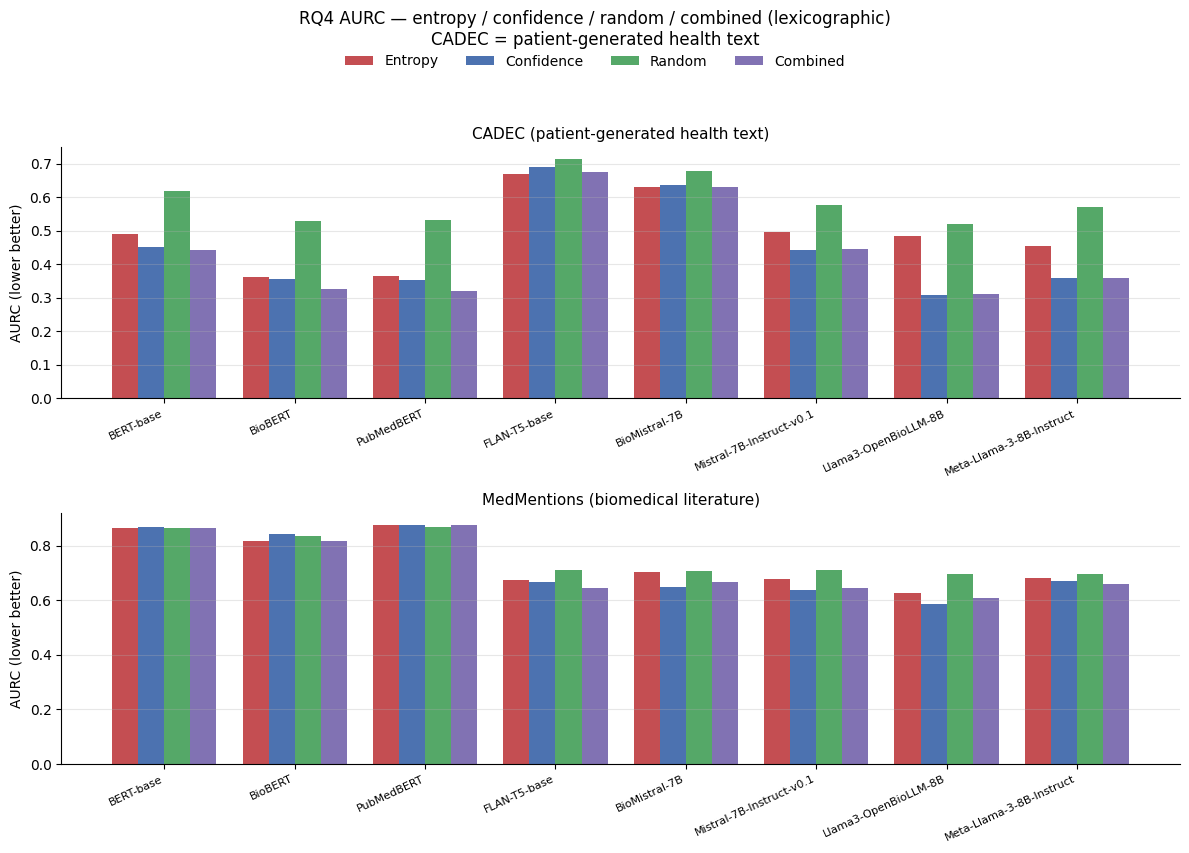

Wrote /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq4_aurc_grouped_both_datasets.png
Wrote /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq3/figures/rq4_aurc_grouped_both_datasets.png


In [4]:
# === Export + figure + verdict ================================================
# Combined summary across both datasets
OUT_COMBINED = PROJECT_ROOT / "outputs" / "rq4_aurc_summary_both_datasets.csv"
OUT_COMBINED.parent.mkdir(parents=True, exist_ok=True)
df_aurc_all.to_csv(OUT_COMBINED, index=False)
print(f"Wrote {OUT_COMBINED} ({len(df_aurc_all)} rows)")

# Also write a copy under each dataset dir for convenience
for ds_key, cfg in DATASETS.items():
    sub = df_aurc_all[df_aurc_all["dataset"] == ds_key]
    p = cfg["out_dir"] / "rq4_aurc_summary.csv"
    sub.to_csv(p, index=False)
    print(f"Wrote {p}")

# Headline confirmation
viol = df_aurc_all[~df_aurc_all["combined_le_both_singles"]]
print("\n=== HEADLINE: AURC_combined ≤ AURC_entropy and ≤ AURC_confidence ===")
if len(viol) == 0:
    print(f"CONFIRMED for all {len(df_aurc_all)} model×dataset cells.")
else:
    print(f"FLAG: {len(viol)} cell(s) violate the headline:")
    print(viol[[
        "dataset", "model", "AURC_entropy", "AURC_confidence", "AURC_combined",
        "combined_le_entropy", "combined_le_confidence",
    ]].round(6).to_string(index=False))

# Grouped AURC figure: 2 panels (datasets) × grouped bars (signals) per model
signals = ["AURC_entropy", "AURC_confidence", "AURC_random", "AURC_combined"]
sig_labels = ["Entropy", "Confidence", "Random", "Combined"]
sig_colors = ["#C44E52", "#4C72B0", "#55A868", "#8172B3"]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
for ax, ds_key in zip(axes, ["CADEC", "MedMentions"]):
    cfg = DATASETS[ds_key]
    sub = df_aurc_all[df_aurc_all["dataset"] == ds_key].copy()
    # preserve model order
    sub["_ord"] = sub["model"].map({m: i for i, m in enumerate(MODEL_ORDER)})
    sub = sub.sort_values("_ord")
    models = sub["model"].tolist()
    x = np.arange(len(models))
    width = 0.2
    for i, (col, lab, colr) in enumerate(zip(signals, sig_labels, sig_colors)):
        vals = sub[col].to_numpy()
        ax.bar(x + (i - 1.5) * width, vals, width, label=lab, color=colr)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=25, ha="right", fontsize=8)
    ax.set_ylabel("AURC (lower better)")
    ax.set_title(cfg["label"], fontsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle(
    "RQ4 AURC — entropy / confidence / random / combined (lexicographic)\n"
    "CADEC = patient-generated health text",
    y=1.06, fontsize=12,
)
fig.tight_layout()
FIG_BOTH = PROJECT_ROOT / "outputs" / "rq4_aurc_grouped_both_datasets.png"
# also save under rq3 figures as primary display location
FIG_RQ3 = DATASETS["CADEC"]["fig_dir"] / "rq4_aurc_grouped_both_datasets.png"
FIG_RQ1 = DATASETS["MedMentions"]["fig_dir"] / "rq4_aurc_grouped_both_datasets.png"
fig.savefig(FIG_BOTH, dpi=160, bbox_inches="tight")
fig.savefig(FIG_RQ3, dpi=160, bbox_inches="tight")
fig.savefig(FIG_RQ1, dpi=160, bbox_inches="tight")
plt.show()
print(f"Wrote {FIG_BOTH}")
print(f"Wrote {FIG_RQ3}")


## 3b) Risk–coverage panels (include combined)

Plotting only — reads `df_curves_all` / existing `*_risk_coverage_*.csv`.


In [ ]:
# === Risk–coverage panels (plotting only; curves already in df_curves_all / CSVs) ===
# Adds signal=="combined" alongside entropy / mapping_confidence / random.
# Dashed purple: on MedMentions encoders combined == entropy (constant confidence).

_plot_specs = [
    ("entropy", "-", "#C44E52", "Semantic entropy"),
    ("mapping_confidence", "-.", "#4C72B0", "Mapping confidence"),
    ("random", "--", "#55A868", "Random"),
    ("combined", "--", "#7a52a8", "combined"),
]

ALL_FIG = PROJECT_ROOT / "all_rq_figures"
ALL_FIG.mkdir(parents=True, exist_ok=True)

for ds_key, cfg in DATASETS.items():
    # Prefer in-memory curves; fall back to on-disk CSV (no recompute)
    if "df_curves_all" in dir() and len(df_curves_all):
        df_curves = df_curves_all[df_curves_all["dataset"] == ds_key].copy()
    else:
        df_curves = pd.read_csv(cfg["out_dir"] / cfg["curve_csv"])
    assert "combined" in set(df_curves["signal"]), (
        f"combined missing from {ds_key} curves — refuse to plot without it"
    )

    models = [m for m in MODEL_ORDER if m in set(df_curves["model"])]
    n_models = len(models)
    ncols = min(4, n_models)
    nrows = int(np.ceil(n_models / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(4.0 * ncols, 3.4 * nrows),
        sharex=False, sharey=True,  # sharey auto; sharex=False so every panel keeps Coverage label
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, model in zip(axes, models):
        sub = df_curves[df_curves["model"] == model]
        for signal, style, color, label in _plot_specs:
            s = sub[sub["signal"] == signal].sort_values("coverage")
            if s.empty:
                continue
            ax.plot(
                s["coverage"], s["risk"],
                linestyle=style, marker="o", markersize=3, linewidth=1.6,
                color=color, label=label,
            )
        ax.set_title(model, fontsize=10)
        ax.set_xlabel("Coverage")
        ax.set_ylabel("Risk")
        ax.set_xlim(0.08, 1.02)
        ax.grid(True, alpha=0.3)
        # y-limits left auto (do not set_ylim) so CADEC encoder dips stay visible

    for ax in axes[n_models:]:
        ax.axis("off")

    for _ax in axes[:n_models]:
        _ax.set_xlabel("Coverage")
        _ax.set_ylabel("Risk")
        _ax.tick_params(labelbottom=True)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc="upper center", ncol=4, frameon=False,
        bbox_to_anchor=(0.5, 1.02),
    )
    fig.suptitle(
        f"RQ4 risk-coverage on {ds_key}\n"
        "risk = 1 − selective accuracy; lower is better",
        y=1.06, fontsize=12,
    )
    plt.tight_layout()

    out_local = cfg["fig_dir"] / f"rq4_risk_coverage_{ds_key.lower()}.png"
    out_all = ALL_FIG / f"RQ4_risk_coverage_{ds_key.lower()}.png"
    fig.savefig(out_local, dpi=150, bbox_inches="tight")
    fig.savefig(out_all, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {out_local}")
    print(f"Saved {out_all}")


## 4) Per-dataset narrative

In [5]:
# === Narrative ================================================================
print("=" * 78)
print("RQ4 AURC SUMMARY (lower is better)")
print("CADEC = patient-generated health text (not clinical notes)")
print("Combined = lexicographic(entropy↑keep-low, confidence↑keep-high)")
print("=" * 78)

for ds_key in ("CADEC", "MedMentions"):
    cfg = DATASETS[ds_key]
    sub = df_aurc_all[df_aurc_all["dataset"] == ds_key].copy()
    sub["_ord"] = sub["model"].map({m: i for i, m in enumerate(MODEL_ORDER)})
    sub = sub.sort_values("_ord")
    print(f"\n### {cfg['label']}")
    for _, r in sub.iterrows():
        flag = "" if r["combined_le_both_singles"] else "  *** FLAG: combined worse than a single ***"
        print(
            f"  {r['model']:28s}  "
            f"ent={r['AURC_entropy']:.4f}  conf={r['AURC_confidence']:.4f}  "
            f"rand={r['AURC_random']:.4f}  comb={r['AURC_combined']:.4f}"
            f"{flag}"
        )
    best = sub.sort_values("AURC_combined").iloc[0]
    print(
        f"  Best combined AURC: {best['model']} = {best['AURC_combined']:.4f} "
        f"(entropy={best['AURC_entropy']:.4f}, confidence={best['AURC_confidence']:.4f})"
    )

n_ok = int(df_aurc_all["combined_le_both_singles"].sum())
n_tot = len(df_aurc_all)
print(f"\nHeadline hold rate: {n_ok}/{n_tot} model×dataset cells")
print(f"\nArtifacts:\n  {OUT_COMBINED}\n  {FIG_BOTH}")


RQ4 AURC SUMMARY (lower is better)
CADEC = patient-generated health text (not clinical notes)
Combined = lexicographic(entropy↑keep-low, confidence↑keep-high)

### CADEC (patient-generated health text)
  BERT-base                     ent=0.4916  conf=0.4528  rand=0.6179  comb=0.4427
  BioBERT                       ent=0.3611  conf=0.3580  rand=0.5300  comb=0.3253
  PubMedBERT                    ent=0.3645  conf=0.3523  rand=0.5334  comb=0.3221
  FLAN-T5-base                  ent=0.6710  conf=0.6892  rand=0.7142  comb=0.6770  *** FLAG: combined worse than a single ***
  BioMistral-7B                 ent=0.6307  conf=0.6357  rand=0.6800  comb=0.6319  *** FLAG: combined worse than a single ***
  Mistral-7B-Instruct-v0.1      ent=0.4958  conf=0.4416  rand=0.5786  comb=0.4470  *** FLAG: combined worse than a single ***
  Llama3-OpenBioLLM-8B          ent=0.4861  conf=0.3100  rand=0.5193  comb=0.3104  *** FLAG: combined worse than a single ***
  Meta-Llama-3-8B-Instruct      ent=0.4561  conf